# STRATEGY PARAMETER OPTIMIZATION PIPELINE (OPTUNA)

Purpose:
- Optimizes trading strategy parameters (RSI, ADX, ATR multipliers, etc.)
- Uses the "Predicted Signal" generated by the ML model as the core input.
- Implements a custom TrialAccumulator with Percentile Pruning for efficiency.
- Simulates trading day-by-day to maximize a specific objective (e.g., Net Profit).
- Saves best-performing parameter sets to CSV and JSON for deployment.

In [3]:
%matplotlib inline

# 1) Wipe out namespace and Jupyter caches
%reset -f
try:
    Out.clear()
    In.clear()
except NameError:
    pass

# 2) Force Python GC and Free GPU (though this notebook is primarily CPU-bound)
import gc
import torch
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# 3) Reload and Core Imports
import importlib
from libs import params, preps, feats, strats, opts, models_core
importlib.reload(params)
importlib.reload(preps)
importlib.reload(feats)
importlib.reload(strats)
importlib.reload(opts)
importlib.reload(models_core)

import numpy as np
import pandas as pd
import math
import os
import json
import re
import psutil
from pathlib import Path
import datetime as dt
from datetime import datetime, time

# 4) Optimization & Progress Visualization
import optuna
from optuna.trial import TrialState
from optuna.importance import get_param_importances
from optuna.visualization.matplotlib import plot_optimization_history
from optuna.storages import RDBStorage
from optuna.samplers import TPESampler

from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from pprint import pprint
from IPython.display import clear_output, display

# 5) Global Configurations
pd.set_option('display.max_columns', None)
plt.ioff()  # Turn off interactive plotting; we manage display via opts
torch.serialization.add_safe_globals([models_core.DayWindowDataset])

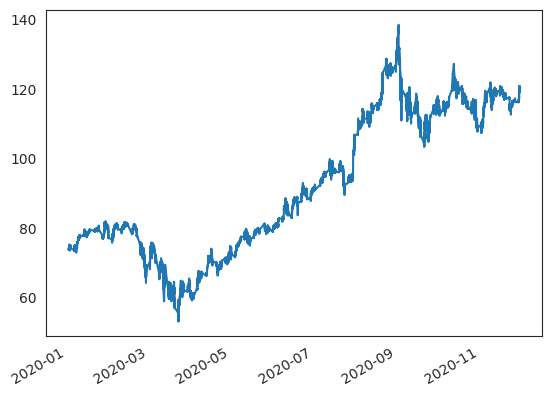

,donch_w_20,atr_28_RZ,range_pct,time_premark,dist_low_100,stoch_k_14_3_3,kc_h_20_20_2.0_RZ,kc_w_20_20_2.0,bb_w_50_2p0,donch_h_20_RZ,ret_std_21,sma_pct_5,trade_count,atr_pct_7,minus_di_14,sma_pct_21,time_day_of_year,upper_shad,ret,time_in_sess,high_RZ,bb_hband_20_3p0_RZ,minus_di_28,roc_5,time_afthour,stoch_d_9_3_3,macd_diff_12_26_9_RZ,atr_pct_14,rsi_7,adx_21,time_minute,sma_pct_9,sma_9_RZ,donch_w_55,rsi_21,minus_di_7,rsi_28,time_hour,rsi_14,cci_20,volume,atr_pct_28,close_raw,targ_signal,signal_thresh,atr_21_raw,adx_21_raw,rsi_21_raw,vwap_ohlc_close_session_raw,pred_signal,ask,bid
2020-01-02 08:59:00,0.050543,0.149225,0.098985,1.0,0.329674,1.000000,0.412362,0.044221,0.029624,0.502622,0.036744,0.530364,0.002431,0.057709,0.070931,0.566508,0.502740,0.000000,0.516552,0.0,0.460992,0.266339,0.130441,0.535011,0.0,1.000000,0.524400,0.044410,0.954385,0.594558,0.311806,0.539945,0.484359,0.056494,0.884812,0.009629,0.912708,0.270833,0.888187,0.719717,0.004457,0.046561,73.961667,0.0,0.137157,0.009955,47.457032,80.998339,73.866909,0.038602,73.976459,73.946874
2020-01-02 09:00:00,0.052997,0.154928,0.113119,1.0,0.332145,1.000000,0.413558,0.049115,0.031860,0.504587,0.036640,0.530362,0.002742,0.068618,0.053886,0.567619,0.502740,0.000000,0.516551,0.0,0.471590,0.269191,0.109560,0.535009,0.0,1.000000,0.526407,0.051221,0.960932,0.604417,0.312500,0.541752,0.484901,0.052183,0.893926,0.006756,0.920039,0.312500,0.899024,0.712298,0.004978,0.050041,73.965833,0.0,0.137157,0.010856,48.120182,81.689118,73.868826,0.042686,73.980626,73.951040
2020-01-02 09:01:00,0.055451,0.160670,0.127252,1.0,0.334616,1.000000,0.414813,0.054695,0.034413,0.505958,0.036513,0.530360,0.003053,0.080406,0.040112,0.568520,0.502740,0.000000,0.516550,0.0,0.482188,0.280117,0.089612,0.535007,0.0,1.000000,0.528611,0.058838,0.966627,0.614799,0.313194,0.541750,0.485396,0.041411,0.902809,0.004744,0.927278,0.312500,0.909229,0.708879,0.005498,0.054080,73.970000,0.0,0.137157,0.011887,48.818592,82.362369,73.870937,0.047320,73.984794,73.955206
2020-01-02 09:02:00,0.056326,0.165655,0.123985,1.0,0.335975,1.000000,0.415951,0.059781,0.037030,0.507389,0.036409,0.525065,0.003011,0.089948,0.030193,0.566498,0.502740,0.000000,0.509297,0.0,0.494405,0.300209,0.073052,0.531762,0.0,1.000000,0.529718,0.065613,0.969525,0.625228,0.313889,0.537679,0.485982,0.036133,0.907648,0.003451,0.931250,0.312500,0.914671,0.707191,0.005252,0.057817,73.972292,0.0,0.137157,0.012829,49.520175,82.729090,73.872921,0.049415,73.987086,73.957497
2020-01-02 09:03:00,0.057202,0.172156,0.120719,1.0,0.337334,1.000000,0.416987,0.064397,0.039676,0.509481,0.036302,0.521094,0.002969,0.097562,0.022721,0.564402,0.502740,0.000000,0.509297,0.0,0.498678,0.304326,0.059095,0.528517,0.0,1.000000,0.530495,0.071605,0.972366,0.635706,0.314583,0.534118,0.486762,0.037316,0.912516,0.002557,0.935256,0.312500,0.920096,0.706987,0.005006,0.061264,73.974583,0.0,0.137157,0.013686,50.225024,83.098084,73.874787,0.049669,73.989378,73.959788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-11-30 23:55:00,0.154461,0.177907,0.168010,0.0,0.172153,0.236559,0.391297,0.137342,0.114824,0.502864,0.150951,0.596163,0.013486,0.158247,0.322972,0.422214,0.415069,0.155159,0.547860,0.0,0.417525,0.309873,0.339914,0.573217,1.0,0.206309,0.415749,0.142229,0.450593,0.225647,0.934028,0.557600,0.426928,0.103078,0.388949,0.234339,0.415554,0.895833,0.376151,0.393288,0.005426,0.140963,120.670000,0.0,0.284815,0.045534,22.640572,43.415530,119.302179,0.004781,120.694134,120.645866
2020-11-30 23:56:00,0.154448,0.178123,0.071998,0.0,0.175801,0.311828,0.389248,0.134876,0.112086,0.502864,0.151893,0.583169,0.010941,0.147690,0.307138,0.439910,0.415069,0.000000,0.524143,0.0,0.412626,0.304500,0.329693,0.583823,1.0,0.315178,0.468823,0.138287,0.484213,0.211314,0.934722,0.569239,0.427557,0.103069,0.404103,0.214890,0.427235,0.895833,0.39703

In [4]:
# ###### ML STRATEGIES DF ######

# Read the Parquet file (schema and datetime index are preserved automatically)
df_opt = pd.read_parquet(params.pred_trainval_pqt) #### pred_trainval_pqt or pred_test_pqt

# Filter dates
df_opt = df_opt[(df_opt.index >= params.start_date_sim) & (df_opt.index < params.end_date_sim)] #########################

df_opt.close_raw.plot()
plt.show()

df_opt

In [6]:
# 'thresh_type': {'categorical': ['roll_mean', 'roll_median']},
#  'thresh_window': (182, 286),
#  'rsi_min_thresh': (31, 35),
#  'rsi_max_thresh': (70, 74),
#  'adx_thresh': (35.6593300712178, 49.21339992878219),
#  'trailstop_pct': (2.9301722911696646, 5.978557708830335),
#  'atr_mult': (2.392301784752533, 2.8525082152474672),
#  'vwap_atr_mult': (-18.649181947747703, -16.27334805225229),
#  'buy_factor': (1.323597686070334, 1.684812313929666),
#  'sell_factor': (0.10895992678801521, 0.2785800732119848)}

In [7]:
col_signal = "pred_signal"

prun_perc = 80 # higher value means the pruner keeps more trials (e.g., 90 keeps the top 10%)
report_interval = 50

def objective(trial: optuna.Trial) -> float:
    # --- 1. Threshold Search ---
    thresh_type = trial.suggest_categorical("thresh_type", ['roll_mean', 'roll_median'])
    
    # Assign values based on the strategy
    # If numeric, use a float. If rolling, suggest a window. Otherwise, use the string.
    if thresh_type == "numeric":
        thresh_mode = trial.suggest_float("thresh_numeric_val", 0.01, 1.5)
        thresh_window = None
    else:
        thresh_mode = thresh_type
        thresh_window = trial.suggest_int("thresh_window", 150, 300) if "roll" in thresh_type else None

    # --- 2. Range Strategy Filters ---
    # Wider bounds to let the optimizer find the ML model's "sweet spot"
    rsi_min_thresh  = trial.suggest_int("rsi_min_thresh", 25, 40)
    rsi_max_thresh  = trial.suggest_int("rsi_max_thresh", 65, 80)
    adx_thresh      = trial.suggest_float("adx_thresh", 30.0, 55.0)
    
    # Multipliers and Stop Losses
    trailstop_pct   = trial.suggest_float("trailstop_pct", 1.5, 6.5)
    atr_mult        = trial.suggest_float("atr_mult", 1.5, 3.5)
    vwap_atr_mult   = trial.suggest_float("vwap_atr_mult", -25.0, -10.0)
    
    # Asymmetrical entry/exit factors (ML models often have different bias for Long vs Short)
    buy_factor      = trial.suggest_float("buy_factor", 0.5, 2.5)
    sell_factor     = trial.suggest_float("sell_factor", 0.1, 1.0)

    print("-" * 160)
    print("Params => " + "; ".join(f"{k}={v}" for k, v in dict(trial.params).items()))

    # --- 3. Processing & Simulation ---
    # Apply the chosen thresholding method
    df_thresh = preps.apply_thresholds_per_day(
        df              = df_opt.copy(),
        col_signal      = col_signal,
        thresh_mode     = thresh_mode,
        thresh_window   = thresh_window
    )

    # Reset simulation environment
    start_ask = float(df_thresh["ask"].iloc[0])
    strats.reset_globals(start_ask)

    groups = list(df_thresh.groupby(df_thresh.index.normalize()))
    pbar = tqdm(groups, total=len(groups), desc=f"Trial {trial.number}", leave=True)
    acc = opts.TrialAccumulator(trial, pbar, report_interval=report_interval, prun_perc=prun_perc)
    
    for step, (day, df_day) in enumerate(pbar, 1):
        df_actions = strats.generate_actions(
            df              = df_day,
            col_signal      = col_signal,
            sign_thresh     = "signal_thresh",
            col_atr         = 'atr_21_raw',
            col_adx         = 'adx_21_raw',
            col_rsi         = 'rsi_21_raw',
            col_vwap        = 'vwap_ohlc_close_session_raw',
            rsi_min_thresh  = rsi_min_thresh,
            rsi_max_thresh  = rsi_max_thresh,
            adx_thresh      = adx_thresh,
            trailstop_pct   = trailstop_pct,
            atr_mult        = atr_mult,
            vwap_atr_mult   = vwap_atr_mult,
            buy_factor      = buy_factor,
            sell_factor     = sell_factor,
            col_close       = 'close_raw'
        )

        sim_results = strats.simulate_trading(day=day, df=df_actions)
        acc.process(sim_results, step, parse_eq_value_callable=strats._parse_eq_value)
        
        if trial.should_prune():
            del df_actions, sim_results, df_thresh, groups  # Added this
            raise optuna.exceptions.TrialPruned()

        del df_actions, sim_results

    final_val = acc.finalize()
    del df_thresh, groups
    gc.collect() 
    return final_val

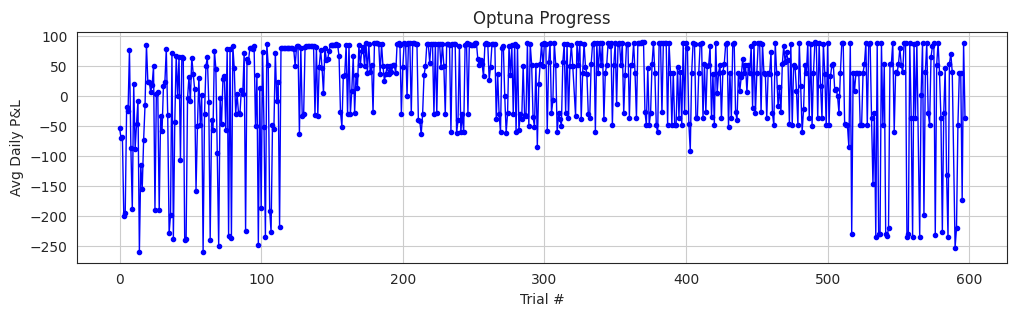

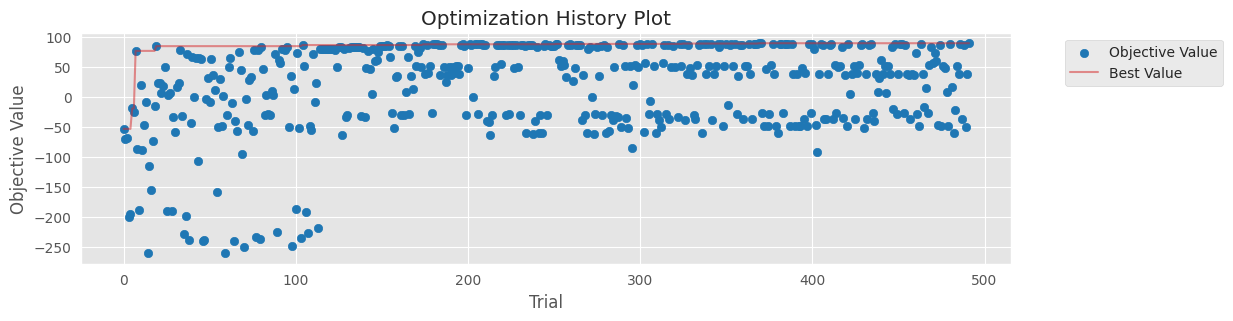

----------------------------------------------------------------------------------------------------------------------------------------------------------------
Params => thresh_type=roll_median; thresh_window=201; rsi_min_thresh=27; rsi_max_thresh=69; adx_thresh=30.341442868552672; trailstop_pct=5.826570887275705; atr_mult=2.469326774152833; vwap_atr_mult=-22.56315352235845; buy_factor=0.7806964938615404; sell_factor=0.679157934894477


Thresh per day:   0%|          | 0/231 [00:00<?, ?it/s]

Trial 0: 100%|██████████| 231/231 [00:12<00:00, 19.22it/s]


[Results] mean_pnl:212.9912 mean_bh:266.4504 mean_excess:-53.4592 improv_vs_bh:-20.06%
Action counts: {'Buy': 313, 'Sell': 18, 'Hold': 202080}
Best trial is: 0 with best_val: -53.4592
[save_results] wrote optuna_results/AAPL_-53.4592_pred_ML.csv
[save_best_json] wrote optuna_results/AAPL_-53.4592_pred_ML.json
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Params => thresh_type=roll_mean; thresh_window=161; rsi_min_thresh=30; rsi_max_thresh=65; adx_thresh=33.23474298963603; trailstop_pct=2.2536811689020366; atr_mult=2.4029664529677612; vwap_atr_mult=-22.090909126624254; buy_factor=1.1373779920641576; sell_factor=0.32773950112775097


Thresh per day:   0%|          | 0/231 [00:00<?, ?it/s]

...

Trial 597: 100%|██████████| 231/231 [00:11<00:00, 20.36it/s]


[Results] mean_pnl:229.7331 mean_bh:266.4504 mean_excess:-36.7173 improv_vs_bh:-13.78%
Action counts: {'Buy': 767, 'Sell': 5, 'Hold': 201639}
Best trial is: 491 with best_val: 89.0832
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Params => thresh_type=roll_mean; thresh_window=274; rsi_min_thresh=39; rsi_max_thresh=80; adx_thresh=34.0095809082974; trailstop_pct=5.46751189111035; atr_mult=3.1910968446870207; vwap_atr_mult=-20.512223228616083; buy_factor=0.6224740231169488; sell_factor=0.1203094327883774


Thresh per day:   0%|          | 0/231 [00:00<?, ?it/s]

Trial 598:  36%|███▋      | 84/231 [00:04<00:08, 17.82it/s]


KeyboardInterrupt: 

In [9]:
# --- STUDY CONFIGURATION ---

n_trials          = 5000
n_startup_trials  = 300 

opts.init_optuna_displays()
optuna.logging.set_verbosity(optuna.logging.ERROR)

# sampler = optuna.samplers.TPESampler(n_startup_trials=n_startup_trials, multivariate=True)

pruner = optuna.pruners.PercentilePruner(
    percentile=prun_perc, 
    n_startup_trials=n_startup_trials, 
    n_warmup_steps=math.ceil(math.ceil(len(df_opt.index.normalize().unique()) / report_interval) * 0.3)
)

study = optuna.create_study(
    pruner=pruner, 
    # sampler=sampler, 
    direction="maximize"
)

# Run Optimization
study.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[
        opts.plot_callback, 
        opts.short_log_callback, 
        opts.make_save_results_callback("pred_ML"), 
        opts.make_save_best_json_callback("pred_ML")
    ],
    gc_after_trial=True
)